# **Project Name: Tourism Experience Analytics** 
#### **(Classification, Prediction, and Recommendation System)**

#### **Project Type**: EDA/Classification/Regression/Recommendation System

#### **Contribution**: Individual

# **Project Summary**:

## Project Overview

This project delivers an end-to-end Machine Learning and Exploratory Data Analysis pipeline tailored for the tourism domain. Using user demographic information, attraction metadata, and historical transaction logs, the project addresses three primary business objectives: predicting user rating satisfaction, classifying visit travel modes, and delivering personalized attraction recommendations.

## Key Objectives & Accomplishments

### 1. Data Preprocessing & Consolidation

* Merged multi-table relational datasets (Transactions, Users, Items, Cities, Continents, Countries, Regions, Visit Modes, and Attraction Types).


* Handled temporal variables (`VisitYear`, `VisitMonth`) and fixed missing location values across categorical hierarchies.


* Applied Label Encoding and One-Hot Encoding to categorical attributes to prepare features for model training.

### 2. Exploratory Data Analysis (EDA)

* Analyzed user demographic distributions globally using hierarchical **Plotly Sunburst** charts.


* Evaluated attraction type popularity using review volume and weighted Bayesian score averages.


* Quantified association between demographic features and `VisitMode` using **Cramér's V statistic** and proportion heatmaps.


* Examined rating variance across top geographic regions and individual tourist destinations.

### 3. Predictive Modeling & Evaluation

#### Regression Task: Predicting Attraction Ratings

* **Goal:** Estimate satisfaction ratings ($1.0 - 5.0$ scale) based on demographic, temporal, and attraction features.

* **Models Trained:** Random Forest Regressor, LightGBM Regressor, XGBoost Regressor.

* **Evaluation Metrics:** Evaluated using Mean Squared Error (MSE), Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and $R^2$ score.

#### Classification Task: Predicting Visit Mode

* **Goal:** Classify travel context (`Business`, `Family`, `Couples`, `Friends`, etc.) to assist target marketing campaigns.

* **Models Trained:** Random Forest Classifier, LightGBM Classifier, XGBoost Classifier.

* **Evaluation Metrics:** Evaluated using Stratified Accuracy, Precision, Recall, and weighted F1-Score.

#### Recommendation Systems

* **User-Based Collaborative Filtering:** Built a User-Item interaction matrix using **Cosine Similarity** to compute $K$-nearest neighbor preferences and recommend top unvisited attractions.

* **Content-Based Filtering:** Feature-engineered metadata vectors (`AttractionType`, `City`, `Country`) to calculate user preference profile vectors and find similar attractions.

* **Evaluation:** Assessed recommendation performance using Root Mean Squared Error (**RMSE**) and Mean Average Precision at K (**MAP@K**).

## Interactive Streamlit Application

A multi-tab Streamlit dashboard (`app.py`) was constructed to deploy the trained models, featuring:

* **Visit Mode Predictor:** Interactive form to predict likely visit modes from user demographic inputs.


* **Personalized Recommendations:** Top-$N$ attraction recommendations generator for selected user profiles.


* **Analytics Dashboard:** Dynamic Plotly visuals for popular attractions, regional hotspots, and demographic user segments.

## Tech Stack

* **Language & Core:** Python, Pandas, NumPy

* **Machine Learning:** Scikit-Learn, LightGBM, XGBoost

* **Visualization:** Seaborn, Matplotlib, Plotly Express

* **Deployment:** Streamlit, Joblib / Pickle

# **GitHub Link**: 
https://github.com/CodeDanish/Tourism_Experience_Analytics

# **Problem Statement**: 

Tourism agencies and travel platforms aim to enhance user experiences by leveraging data to provide personalized recommendations, predict user satisfaction, and classify potential user behavior. This project involves analyzing user preferences, travel patterns, and attraction features to achieve three primary objectives: regression, classification, and recommendation. 

# **Objective**: 

1. Regression: Predicting Attraction Ratings
   
Aim: 
Develop a regression model to predict the rating a user might give to a tourist attraction based on historical data, user demographics, and attraction features.

Use Case: 

● Travel platforms can use this model to estimate the satisfaction level of users visiting specific attractions. By identifying attractions likely to receive lower ratings, agencies can take corrective actions, such as improving services or better setting user expectations. 

● Personal travel guides can provide users with attractions most aligned with their preferences to enhance overall satisfaction. 

Possible Inputs (Features): 

● User demographics: Continent, region, country, city. 

● Visit details: Year, month, mode of visit (e.g., business, family, friends). 

● Attraction attributes: Type (e.g., beaches, ruins), location, and previous average ratings. 

Target: 

● Predicted rating (on a scale, e.g., 1-5).

2. Classification: User Visit Mode Prediction

Aim:
Create a classification model to predict the mode of visit (e.g., business, family, couples, friends) based on user and attraction data. 

Use Case: 

● Travel platforms can use this model to tailor marketing campaigns. For instance, if a user is predicted to travel with family, family-friendly packages can be promoted. 

● Hotels and attraction organizers can plan resources (e.g., amenities) better based on predicted visitor types. 

Inputs (Features): 

● User demographics: Continent, region, country, city. 

● Attraction characteristics: Type, popularity, previous visitor demographics. 

● Historical visit data: Month, year, previous visit modes. 

Target:

● Visit mode (categories: Business, Family, Couples, Friends, etc.).

3. Recommendations: Personalized Attraction Suggestions

Objective: 
Develop a recommendation system to suggest tourist attractions based on a user's historical preferences and similar users’ preferences. 

Use Case: 

● Travel platforms can implement this system to guide users toward attractions they are most likely to enjoy, increasing user engagement and satisfaction. 

● Destination management organizations can identify emerging trends and promote attractions that align with user preferences. 

Types of Recommendation Approaches: 

1. Collaborative Filtering:

○ Recommend attractions based on similar users’ ratings and preferences.

3. Content-Based Filtering:

○ Suggest attractions similar to those already visited by the user based on features like attraction type, location, and amenities.

4. Hybrid Systems: (Optional)

○ Combine collaborative and content-based methods for enhanced accuracy. 

Inputs (Features): 

● User visit history: Attractions visited, ratings given. 

● Attraction features: Type, location, popularity. 

● Similar user data: Travel patterns and preferences. 

Output: 

● Ranked list of recommended attractions. 
 
 

# **Let's Begin!**

### **Import Libraries**

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
attraction_additional = pd.read_excel("/kaggle/input/datasets/nmkkjj/tourism-experience-dataset/Updated_Item.xlsx")
city = pd.read_excel("/kaggle/input/datasets/nmkkjj/tourism-experience-dataset/City.xlsx")
continent = pd.read_excel("/kaggle/input/datasets/nmkkjj/tourism-experience-dataset/Continent.xlsx")
country = pd.read_excel("/kaggle/input/datasets/nmkkjj/tourism-experience-dataset/Country.xlsx")
item = pd.read_excel("/kaggle/input/datasets/nmkkjj/tourism-experience-dataset/Item.xlsx")
mode = pd.read_excel("/kaggle/input/datasets/nmkkjj/tourism-experience-dataset/Mode.xlsx")
region = pd.read_excel("/kaggle/input/datasets/nmkkjj/tourism-experience-dataset/Region.xlsx")
transaction = pd.read_excel("/kaggle/input/datasets/nmkkjj/tourism-experience-dataset/Transaction.xlsx")
type_attraction = pd.read_excel("/kaggle/input/datasets/nmkkjj/tourism-experience-dataset/Type.xlsx")
user = pd.read_excel("/kaggle/input/datasets/nmkkjj/tourism-experience-dataset/User.xlsx")

### **Dataset First View**

In [40]:
print(attraction_additional.head(2),"\n")
print(city.head(2),"\n","\n")
print(continent.head(2),"\n")
print(country.head(2),"\n")
print(item.head(2),"\n")
print(mode.head(2),"\n")
print(region.head(2),"\n")
print(transaction.head(2),"\n")
print(type_attraction.head(2),"\n")
print(user.head(2),"\n")

   AttractionId  AttractionCityId AttractionTypeId         Attraction  \
0           369                 1               13  Kuta Beach - Bali   
1           481                 1               13     Nusa Dua Beach   

                                AttractionAddress  
0                                            Kuta  
1  Semenanjung Nusa Dua, Nusa Dua 80517 Indonesia   

   CityId CityName  CountryId
0       0        -          0
1       1   Douala          1 
 

   ContinentId Continent
0            0         -
1            1    Africa 

   CountryId   Country  RegionId
0          0         -         0
1          1  Cameroon         1 

   AttractionId  AttractionCityId  AttractionTypeId         Attraction  \
0           369                 1                13  Kuta Beach - Bali   
1           481                 1                13     Nusa Dua Beach   

                                AttractionAddress  
0                                            Kuta  
1  Semenanjung Nusa Dua

### **Dataset Rows & Columns Count**

In [41]:
print("Attraction_Additional data Shape: ",attraction_additional.shape)
print("City data Shape: ",city.shape)
print("Continent data Shape: ",continent.shape)
print("Country data Shape: ",country.shape)
print("Item data Shape: ",item.shape)
print("Mode data Shape: ",mode.shape)
print("Region data Shape: ",region.shape)
print("Transaction data Shape: ",transaction.shape)
print("Type_Attraction data Shape: ",type_attraction.shape)
print("User data Shape: ",user.shape)

Attraction_Additional data Shape:  (1698, 5)
City data Shape:  (9143, 3)
Continent data Shape:  (6, 2)
Country data Shape:  (165, 3)
Item data Shape:  (30, 5)
Mode data Shape:  (6, 2)
Region data Shape:  (22, 3)
Transaction data Shape:  (52930, 7)
Type_Attraction data Shape:  (17, 2)
User data Shape:  (33530, 5)


### **Datset Information**

In [42]:
print("Attraction_Additional data info: ",attraction_additional.info())
print("City data info: ",city.info())
print("Continent data info: ",continent.info())
print("Country data info: ",country.info())
print("Item data info: ",item.info())
print("Mode data info: ",mode.info())
print("Region data info: ",region.info())
print("Transaction data info: ",transaction.info())
print("Type_Attraction data info: ",type_attraction.info())
print("User data info: ",user.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1698 entries, 0 to 1697
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   AttractionId       1698 non-null   int64 
 1   AttractionCityId   1698 non-null   int64 
 2   AttractionTypeId   1698 non-null   object
 3   Attraction         1698 non-null   object
 4   AttractionAddress  1698 non-null   object
dtypes: int64(2), object(3)
memory usage: 66.5+ KB
Attraction_Additional data info:  None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9143 entries, 0 to 9142
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   CityId     9143 non-null   int64 
 1   CityName   9142 non-null   object
 2   CountryId  9143 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 214.4+ KB
City data info:  None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):


### **Duplicate values**

In [43]:
print("Attraction_Additional data Duplicate: ",attraction_additional.duplicated().sum())
print("City data Duplicate: ",city.duplicated().sum())
print("Continent data Duplicate: ",continent.duplicated().sum())
print("Country data Duplicate: ",country.duplicated().sum())
print("Item data Duplicate: ",item.duplicated().sum())
print("Mode data Duplicate: ",mode.duplicated().sum())
print("Region data Duplicate: ",region.duplicated().sum())
print("Transaction data Duplicate: ",transaction.duplicated().sum())
print("Type_Attraction data Duplicate: ",type_attraction.duplicated().sum())
print("User data Duplicate: ",user.duplicated().sum())

Attraction_Additional data Duplicate:  0
City data Duplicate:  0
Continent data Duplicate:  0
Country data Duplicate:  0
Item data Duplicate:  0
Mode data Duplicate:  0
Region data Duplicate:  0
Transaction data Duplicate:  0
Type_Attraction data Duplicate:  0
User data Duplicate:  0


### **Missing Values/Null Values**

From info() of the datasets we come to know that only City and User Data contain Null Values

In [44]:
city.isnull().sum()

CityId       0
CityName     1
CountryId    0
dtype: int64

In [45]:
user.isnull().sum()

UserId         0
ContinentId    0
RegionId       0
CountryId      0
CityId         4
dtype: int64

# **1. Data Cleaning**

In [46]:
transaction["VisitYear"].value_counts()

VisitYear
2016    12823
2017     9444
2015     8687
2018     7461
2019     5913
2014     4808
2013     2983
2020      529
2022      247
2021       35
Name: count, dtype: int64

In [47]:
transaction["VisitMonth"].value_counts()

VisitMonth
8     5026
9     4917
7     4861
10    4715
12    4542
1     4458
4     4445
6     4361
5     4316
11    3846
3     3772
2     3671
Name: count, dtype: int64

In [48]:
transaction["Rating"].value_counts()

Rating
5    23936
4    17966
3     7730
2     2035
1     1263
Name: count, dtype: int64

Removing Null Values

In [49]:
city.dropna(inplace=True)
user.dropna(inplace=True)

In [50]:
# Converting CityId column of user dataset to int
user["CityId"] = user["CityId"].astype("int64")
user["CityId"].dtype

dtype('int64')

Removing Discrepancies

In [51]:
city.sample(5)

,CityId,CityName,CountryId
1520,1520,Naknek,51
220,220,Lagos,27
2615,2615,Side,88
4501,4501,Kingaroy,109
3872,3872,Blue Mountains,109


In [52]:
city["CityName"].value_counts()

CityName
-                    8
Richmond             5
Kingston             4
Victoria             4
Windsor              4
                    ..
Java                 1
Jayapura             1
Jember               1
Jember Jawa Timur    1
Jakarta Timur        1
Name: count, Length: 8767, dtype: int64

In [53]:
city = city[city["CityName"] != "-"]
city["CityName"].value_counts()

CityName
Richmond             5
Kingston             4
Victoria             4
Windsor              4
Georgetown           4
                    ..
Java                 1
Jayapura             1
Jember               1
Jember Jawa Timur    1
Jakarta Timur        1
Name: count, Length: 8766, dtype: int64

In [54]:
continent = continent[continent["Continent"] != "-"]
continent["Continent"].value_counts()

Continent
Africa                 1
America                1
Asia                   1
Australia & Oceania    1
Europe                 1
Name: count, dtype: int64

In [55]:
country = country[country["Country"] != "-"]

In [56]:
mode = mode[mode["VisitMode"] != "-"]

In [57]:
region = region[region["Region"] != "-"]

Date and Year are already Standardized

No outliers in the datasets

# **2. Preprocessing**

In [58]:
# Encode Categorical Variables
import pandas as pd

# 1. Merge transactional, user, and attraction datasets
merged_df = transaction.merge(user, on="UserId", how="left")
merged_df = merged_df.merge(item, on="AttractionId", how="left")

# 2. Join categorical lookup tables to get text descriptions
if "df_city" in locals():
    merged_df = merged_df.merge(city, on="CityId", how="left")

if "df_type" in locals():
    merged_df = merged_df.merge(type, on="AttractionTypeId", how="left")

if "df_visit_mode" in locals():
    # If VisitMode is stored as an ID in transactions
    if "VisitModeId" in transaction.columns:
        merged_df = merged_df.merge(
            mode, on="VisitModeId", how="left"
        )

if "df_continent" in locals():
    merged_df = merged_df.merge(continent, on="ContinentId", how="left")

if "df_country" in locals():
    merged_df = merged_df.merge(country, on="CountryId", how="left")

if "df_region" in locals():
    merged_df = merged_df.merge(region, on="RegionId", how="left")

# Verify the merged dataset shape and columns
print("Merged DataFrame Shape:", merged_df.shape)
print("Columns in merged_df:", merged_df.columns.tolist())

Merged DataFrame Shape: (52930, 15)
Columns in merged_df: ['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode', 'AttractionId', 'Rating', 'ContinentId', 'RegionId', 'CountryId', 'CityId', 'AttractionCityId', 'AttractionTypeId', 'Attraction', 'AttractionAddress']


In [59]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder


def encode_categorical_features(df):
    """Encode categorical features (VisitMode, Continent, Country, AttractionTypeId)

    for machine learning modeling.
    """
    df_encoded = df.copy()

    categorical_cols = [
        "VisitMode",
        "Continent",
        "Country",
        "AttractionTypeId",
    ]

    # Clean string data before encoding
    for col in categorical_cols:
        if col in df_encoded.columns:
            df_encoded[col] = df_encoded[col].astype(str).str.strip()

    # ---------------------------------------------------------
    # Approach 1: Label Encoding (Recommended for XGBoost / LightGBM)
    # ---------------------------------------------------------
    label_encoders = {}
    for col in categorical_cols:
        if col in df_encoded.columns:
            le = LabelEncoder()
            # Encodes categorical text/IDs into numeric integers (0, 1, 2, ...)
            df_encoded[f"{col}_Label"] = le.fit_transform(df_encoded[col])
            label_encoders[col] = le

    # ---------------------------------------------------------
    # Approach 2: One-Hot Encoding (Recommended for Linear/Distance Models)
    # ---------------------------------------------------------
    # Creates binary indicator columns for each category
    df_onehot = pd.get_dummies(
        df_encoded,
        columns=[c for c in categorical_cols if c in df_encoded.columns],
        drop_first=True,  # Avoids multicollinearity (dummy variable trap)
        dtype=int,
    )

    return df_encoded, df_onehot, label_encoders


# Example Usage:
df_labeled, df_onehot, encoders = encode_categorical_features(merged_df)

In [60]:
# Aggregate User Level Features
import pandas as pd

def create_user_profile_features(df):
    """Aggregates transactional and ratings data to build user-level profile features."""

    # 1. Aggregations on Rating and Travel Activity
    user_general_stats = df.groupby("UserId").agg(
        total_visits=("TransactionId", "count"),
        avg_rating=("Rating", "mean"),
        min_rating=("Rating", "min"),
        max_rating=("Rating", "max"),
        rating_std=("Rating", "std"),
        unique_attractions_visited=("AttractionId", "nunique"),
        unique_cities_visited=(
            "AttractionCityId" if "AttractionCityId" in df else "CityId",
            "nunique",
        ),
    )

    # Fill NaN standard deviation (for users with only 1 visit) with 0
    user_general_stats["rating_std"] = user_general_stats[
        "rating_std"
    ].fillna(0)

    # 2. Aggregation: Average Rating per Visit Mode
    if "VisitMode" in df.columns:
        visit_mode_avg_ratings = df.groupby(["UserId", "VisitMode"])[
            "Rating"
        ].mean()
        # Pivot table to make each Visit Mode a column (e.g., avg_rating_Business, avg_rating_Family)
        visit_mode_pivot = visit_mode_avg_ratings.unstack(
            fill_value=0
        ).add_prefix("avg_rating_")

        # Combine general stats with visit mode stats
        user_profiles = user_general_stats.merge(
            visit_mode_pivot, on="UserId", how="left"
        )
    else:
        user_profiles = user_general_stats

    # 3. Merge back with baseline demographic data (e.g., Continent, Country, Region)
    demographic_cols = [
        col
        for col in ["UserId", "ContinentId", "CountryId", "RegionId", "CityId"]
        if col in df.columns
    ]
    if demographic_cols:
        user_demographics = df[demographic_cols].drop_duplicates(
            subset=["UserId"]
        )
        user_profiles = user_profiles.merge(
            user_demographics, on="UserId", how="left"
        )

    return user_profiles


# Example Usage:
user_profile_df = create_user_profile_features(merged_df)
merged_df_with_profiles = merged_df.merge(user_profile_df, on="UserId", how="left")
print("Columns in merged_df_with_profiles:", merged_df_with_profiles.columns.tolist())

Columns in merged_df_with_profiles: ['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode', 'AttractionId', 'Rating', 'ContinentId_x', 'RegionId_x', 'CountryId_x', 'CityId_x', 'AttractionCityId', 'AttractionTypeId', 'Attraction', 'AttractionAddress', 'total_visits', 'avg_rating', 'min_rating', 'max_rating', 'rating_std', 'unique_attractions_visited', 'unique_cities_visited', 'avg_rating_1', 'avg_rating_2', 'avg_rating_3', 'avg_rating_4', 'avg_rating_5', 'ContinentId_y', 'CountryId_y', 'RegionId_y', 'CityId_y']


In [61]:
# Join relevant data
import pandas as pd


def consolidate_datasets(
    transaction,
    user,
    item,
    city=None,
    type_attraction=None,
    mode=None,
    continent=None,
    country=None,
    region=None,
):
    """Joins transaction, user, city, attraction (item), and lookup tables into a single consolidated DataFrame for EDA and ML pipelines."""
    # 1. Start with core transaction data
    consolidated = transaction.copy()

    # 2. Join User Data on UserId
    if user is not None and "UserId" in user.columns:
        consolidated = consolidated.merge(user, on="UserId", how="left")

    # 3. Join Attraction (Item) Data on AttractionId
    if item is not None and "AttractionId" in item.columns:
        consolidated = consolidated.merge(item, on="AttractionId", how="left")

    # 4. Join City Data
    # Connects via AttractionCityId if available, otherwise CityId
    if city is not None and "CityId" in city.columns:
        if "AttractionCityId" in consolidated.columns:
            consolidated = consolidated.merge(
                city,
                left_on="AttractionCityId",
                right_on="CityId",
                how="left",
                suffixes=("", "_city"),
            )
        elif "CityId" in consolidated.columns:
            consolidated = consolidated.merge(
                city, on="CityId", how="left", suffixes=("", "_city")
            )

    # 5. Join Lookup Tables (Type, Visit Mode, Continent, Country, Region)
    if type_attraction is not None and "AttractionTypeId" in type_attraction.columns:
        consolidated = consolidated.merge(
            type_attraction, on="AttractionTypeId", how="left"
        )

    if mode is not None:
        if (
            "VisitModeId" in consolidated.columns
            and "VisitModeId" in mode.columns
        ):
            consolidated = consolidated.merge(
                mode, on="VisitModeId", how="left"
            )

    if continent is not None and "ContinentId" in continent.columns:
        consolidated = consolidated.merge(
            continent, on="ContinentId", how="left"
        )

    if country is not None and "CountryId" in country.columns:
        consolidated = consolidated.merge(
            country, on="CountryId", how="left"
        )

    # Verify which DataFrame has the missing column
    print("Consolidated columns:", consolidated.columns)
    print("Region columns:", region.columns)
    
    # If region has 'RegionId' but consolidated has 'region_id':
    consolidated = consolidated.merge(
        region, left_on="RegionId_x", right_on="RegionId", how="left"
    )

    return consolidated


# Example Execution:
consolidated_df = consolidate_datasets(
    transaction=transaction,
    user=user,
    item=item,
    city=city,
    type_attraction=type_attraction,
    mode=mode,
    continent=continent,
    country=country,
    region=region
)

Consolidated columns: Index(['TransactionId', 'UserId', 'VisitYear', 'VisitMonth', 'VisitMode',
       'AttractionId', 'Rating', 'ContinentId', 'RegionId_x', 'CountryId',
       'CityId', 'AttractionCityId', 'AttractionTypeId', 'Attraction',
       'AttractionAddress', 'CityId_city', 'CityName', 'CountryId_city',
       'AttractionType', 'Continent', 'Country', 'RegionId_y'],
      dtype='object')
Region columns: Index(['Region', 'RegionId', 'ContinentId'], dtype='object')


In [62]:
# Normalization 
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler


def scale_numerical_features(
    df, numerical_cols=None, method="minmax", drop_original=False
):
    """Scales numerical features (e.g., Rating, VisitYear) using StandardScaler or MinMaxScaler.

    Parameters:
    df (pd.DataFrame): Consolidated dataset.
    numerical_cols (list): List of numerical columns to scale. Defaults to
    ['Rating'].
    method (str): 'minmax' for [0, 1] scaling or 'standard' for z-score
    scaling.
    drop_original (bool): Whether to overwrite original columns or keep scaled
    as new columns.

    Returns:
    pd.DataFrame, scaler: DataFrame with scaled columns and fitted scaler
    object.
    """
    df_scaled = df.copy()

    if numerical_cols is None:
        numerical_cols = ["Rating"]

    # Filter columns present in DataFrame
    valid_cols = [c for c in numerical_cols if c in df_scaled.columns]

    if not valid_cols:
        raise ValueError(
            f"None of the specified columns {numerical_cols} exist in the DataFrame."
        )

    # Initialize scaler choice
    if method == "minmax":
        scaler = MinMaxScaler(feature_range=(0, 1))
    elif method == "standard":
        scaler = StandardScaler()
    else:
        raise ValueError("Method must be either 'minmax' or 'standard'")

    # Fit and transform features
    scaled_values = scaler.fit_transform(df_scaled[valid_cols])

    # Assign back to DataFrame
    for i, col in enumerate(valid_cols):
        target_col = col if drop_original else f"{col}_scaled"
        df_scaled[target_col] = scaled_values[:, i]

    return df_scaled, scaler


# ---------------------------------------------------------
# Example Usage:
# ---------------------------------------------------------

# 1. Scaling 'Rating' for Recommendation / Neural Network Models (Range 0 to 1)
scaled_df, rating_scaler = scale_numerical_features(consolidated_df, numerical_cols=['Rating'], method='minmax')

# 2. Scaling multiple continuous numerical features for Regression Models
num_features = ['Rating', 'VisitYear', 'total_visits', 'avg_rating']
scaled_df, std_scaler = scale_numerical_features(consolidated_df, numerical_cols=num_features, method='standard')

# **3. Exploratory Data Analysis**

/tmp/ipykernel_58/1961963768.py:56: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_58/1961963768.py:70: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




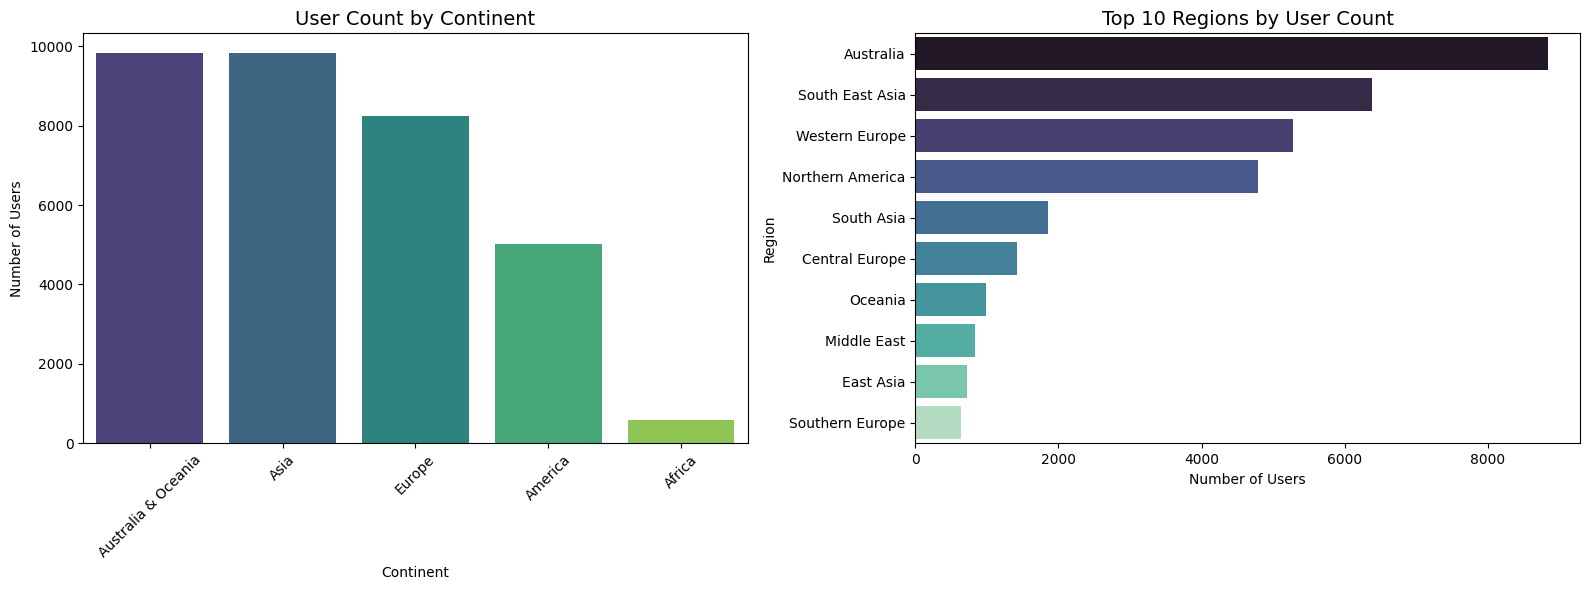

In [63]:
# Visualize user distribution across continents, countries, and regions.

import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

# Ensure you use unique users for demographic distribution
df_unique_users = consolidated_df.drop_duplicates(subset=["UserId"])


# ---------------------------------------------------------
# 1. Interactive Visualizations (Plotly - Best for Streamlit)
# ---------------------------------------------------------


# Interactive Sunburst Chart: Hierarchical View (Continent -> Region -> Country)
def plot_user_demographics_sunburst(df_users):
    fig = px.sunburst(
        df_users,
        path=["Continent", "Region", "Country"],
        title="User Distribution Hierarchy (Continent -> Region -> Country)",
        color_continuous_scale="Viridis",
    )
    fig.update_layout(margin=dict(t=40, l=0, r=0, b=0))
    return fig


# Interactive Bar Chart: Top 10 Countries
def plot_top_countries_bar(df_users, top_n=10):
    country_counts = (
        df_users["Country"].value_counts().head(top_n).reset_index()
    )
    country_counts.columns = ["Country", "User Count"]

    fig = px.bar(
        country_counts,
        x="User Count",
        y="Country",
        orientation="h",
        title=f"Top {top_n} Countries by User Count",
        color="User Count",
        color_continuous_scale="Blues",
    )
    fig.update_layout(yaxis={"categoryorder": "total ascending"})
    return fig

# ---------------------------------------------------------
# 2. Static Visualizations (Seaborn / Matplotlib)
# ---------------------------------------------------------


def plot_static_demographics(df_users):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Continent Distribution
    sns.countplot(
        data=df_users,
        x="Continent",
        order=df_users["Continent"].value_counts().index,
        ax=axes[0],
        palette="viridis",
    )
    axes[0].set_title("User Count by Continent", fontsize=14)
    axes[0].set_xlabel("Continent")
    axes[0].set_ylabel("Number of Users")
    axes[0].tick_params(axis="x", rotation=45)

    # Top Regions Distribution
    top_regions = df_users["Region"].value_counts().head(10).index
    sns.countplot(
        data=df_users[df_users["Region"].isin(top_regions)],
        y="Region",
        order=top_regions,
        ax=axes[1],
        palette="mako",
    )
    axes[1].set_title("Top 10 Regions by User Count", fontsize=14)
    axes[1].set_xlabel("Number of Users")
    axes[1].set_ylabel("Region")

    plt.tight_layout()
    plt.show()


df_complete = df_unique_users.dropna(subset=["Continent", "Region", "Country"])
fig_sunburst = plot_user_demographics_sunburst(df_complete)
fig_sunburst.show()
plot_static_demographics(df_unique_users)

             AttractionType  total_reviews  avg_rating  median_rating  \
15              Water Parks           6429    4.646601            5.0   
7            National Parks            511    4.416830            5.0   
8   Nature & Wildlife Areas          13251    4.266848            4.0   
3           Caverns & Caves            135    4.503704            5.0   
6           History Museums            978    4.256646            4.0   
11          Religious Sites           6711    4.207123            4.0   
12                     Spas             28    4.571429            5.0   
9             Neighborhoods             44    4.318182            5.0   
1                   Ballets            377    4.180371            4.0   
13       Speciality Museums             31    4.032258            4.0   

    rating_std  weighted_score  
15    0.642447        4.620045  
7     0.912028        4.310842  
8     0.874133        4.264091  
3     0.751854        4.255913  
6     0.898413        4.231754 

/tmp/ipykernel_58/7540977.py:78: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




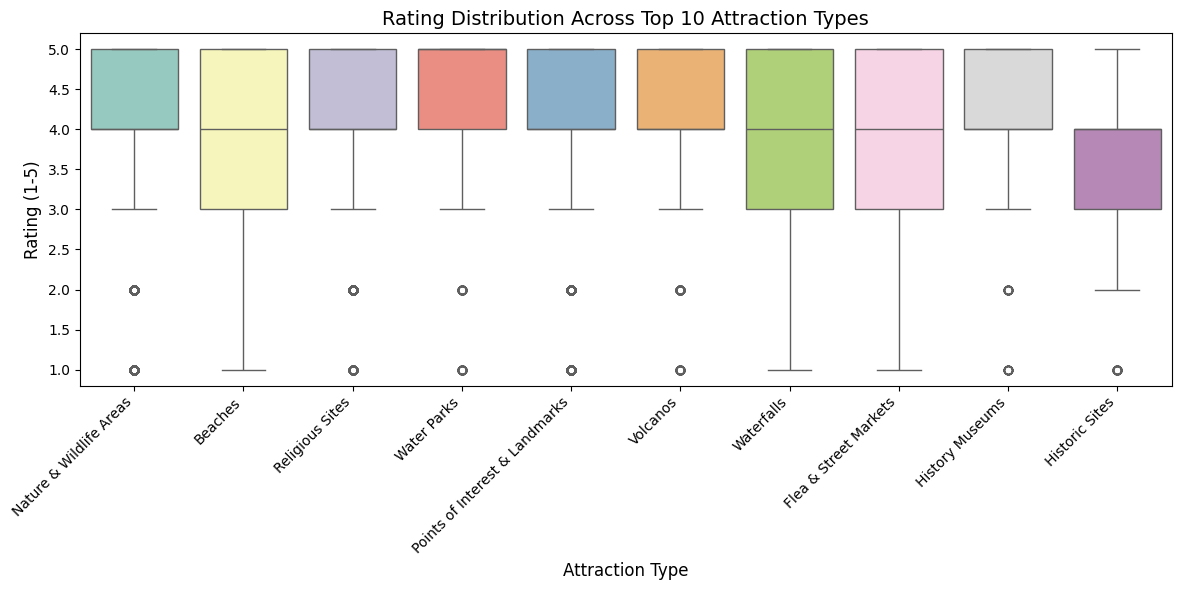

In [64]:
# Explore attraction types and their popularity based on user ratings.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns


def analyze_attraction_type_popularity(df):
    """Analyzes attraction types based on average ratings, rating counts, and popularity metrics."""
    # ---------------------------------------------------------
    # 1. Aggregating Data by Attraction Type
    # ---------------------------------------------------------
    # Identify type column name (AttractionType or AttractionTypeId)
    type_col = "AttractionType" if "AttractionType" in df.columns else "AttractionTypeId"

    type_stats = (
        df.groupby(type_col)
        .agg(
            total_reviews=("Rating", "count"),
            avg_rating=("Rating", "mean"),
            median_rating=("Rating", "median"),
            rating_std=("Rating", "std"),
        )
        .reset_index()
    )

    # Calculate Weighted Rating (Bayesian Average) to account for low review counts
    C = type_stats["avg_rating"].mean()
    m = type_stats["total_reviews"].quantile(0.25)  # Minimum threshold
    type_stats["weighted_score"] = (
        (type_stats["total_reviews"] / (type_stats["total_reviews"] + m))
        * type_stats["avg_rating"]
    ) + ((m / (type_stats["total_reviews"] + m)) * C)

    type_stats = type_stats.sort_values(by="weighted_score", ascending=False)

    return type_stats


# ---------------------------------------------------------
# 2. Plotly Interactive Scatter (Popularity vs. Rating)
# ---------------------------------------------------------
def plot_type_popularity_interactive(type_stats):
    type_col = "AttractionType" if "AttractionType" in type_stats.columns else "AttractionTypeId"

    fig = px.scatter(
        type_stats,
        x="total_reviews",
        y="avg_rating",
        size="weighted_score",
        color=type_col,
        text=type_col,
        title="Attraction Type Popularity: Review Volume vs. Average Rating",
        labels={
            "total_reviews": "Total Visits / Reviews",
            "avg_rating": "Average Rating",
        },
        hover_data=["weighted_score", "median_rating"],
    )
    fig.update_traces(textposition="top center")
    fig.update_layout(showlegend=False, height=500)
    return fig


# ---------------------------------------------------------
# 3. Static Distribution Plots (Seaborn)
# ---------------------------------------------------------
def plot_type_rating_distributions(df):
    type_col = "AttractionType" if "AttractionType" in df.columns else "AttractionTypeId"

    # Get top 10 most visited attraction types
    top_types = df[type_col].value_counts().head(10).index
    df_top = df[df[type_col].isin(top_types)]

    plt.figure(figsize=(12, 6))
    sns.boxplot(
        data=df_top,
        x=type_col,
        y="Rating",
        palette="Set3",
        order=top_types,
    )
    plt.xticks(rotation=45, ha="right")
    plt.title(
        "Rating Distribution Across Top 10 Attraction Types", fontsize=14
    )
    plt.xlabel("Attraction Type", fontsize=12)
    plt.ylabel("Rating (1-5)", fontsize=12)
    plt.tight_layout()
    plt.show()


# Example Execution:
type_summary_df = analyze_attraction_type_popularity(consolidated_df)
print(type_summary_df.head(10))
fig_scatter = plot_type_popularity_interactive(type_summary_df)
fig_scatter.show()
plot_type_rating_distributions(consolidated_df)

Cramér's V Association Scores:
   Demographic_Feature  Cramers_V
2             Country   0.148436
1              Region   0.130264
0           Continent   0.112532


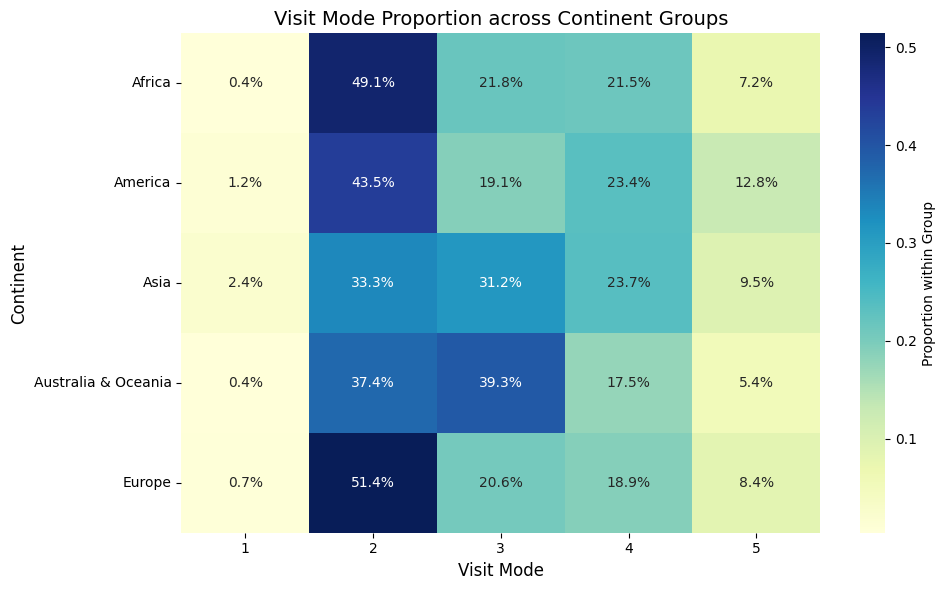

In [65]:
# Investigate correlation between VisitMode and user demographics to identify patterns.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
from scipy.stats import chi2_contingency


# ---------------------------------------------------------
# 1. Cramér's V Statistic (Categorical Correlation)
# ---------------------------------------------------------
def cramers_v(x, y):
    """Calculates Cramér's V statistic for categorical-categorical association."""
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))


def calculate_demographic_correlations(df):
    """Computes categorical correlation (Cramér's V) between VisitMode and demographics."""
    demographic_cols = [
        col
        for col in ["Continent", "Region", "Country"]
        if col in df.columns
    ]
    correlations = {}

    for col in demographic_cols:
        # Filter NaNs
        valid_df = df.dropna(subset=["VisitMode", col])
        score = cramers_v(valid_df["VisitMode"], valid_df[col])
        correlations[col] = score

    corr_df = pd.DataFrame(
        list(correlations.items()), columns=["Demographic_Feature", "Cramers_V"]
    )
    return corr_df.sort_values(by="Cramers_V", ascending=False)


# ---------------------------------------------------------
# 2. Proportion Heatmap (Static - Seaborn)
# ---------------------------------------------------------
def plot_visitmode_demographic_heatmap(df, demographic_col="Continent"):
    """Plots a proportion-normalized heatmap showing VisitMode preference per demographic group."""
    # Cross-tabulation normalized by row (demographic group)
    crosstab_prop = pd.crosstab(
        df[demographic_col], df["VisitMode"], normalize="index"
    )

    plt.figure(figsize=(10, 6))
    sns.heatmap(
        crosstab_prop,
        annot=True,
        fmt=".1%",
        cmap="YlGnBu",
        cbar_kws={"label": "Proportion within Group"},
    )
    plt.title(
        f"Visit Mode Proportion across {demographic_col} Groups", fontsize=14
    )
    plt.xlabel("Visit Mode", fontsize=12)
    plt.ylabel(demographic_col, fontsize=12)
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------
# 3. Interactive Stacked Bar Chart (Plotly - Streamlit Ready)
# ---------------------------------------------------------
def plot_visitmode_demographic_interactive(
    df, demographic_col="Continent", top_n=10
):
    """Generates an interactive 100% stacked bar chart for Streamlit."""
    # Select top N demographic categories if high cardinality (e.g., Country or Region)
    top_categories = (
        df[demographic_col].value_counts().head(top_n).index.tolist()
    )
    filtered_df = df[df[demographic_col].isin(top_categories)]

    # Group counts
    grouped = (
        filtered_df.groupby([demographic_col, "VisitMode"])
        .size()
        .reset_index(name="Count")
    )

    fig = px.bar(
        grouped,
        x=demographic_col,
        y="Count",
        color="VisitMode",
        title=f"Visit Mode Breakdown across Top {top_n} {demographic_col}s",
        labels={demographic_col: demographic_col, "Count": "Number of Visits"},
        barmode="group",  # Or 'stack'
        color_discrete_sequence=px.colors.qualitative.Set2,
    )
    fig.update_layout(height=500)
    return fig


# Example Execution:
corr_summary = calculate_demographic_correlations(consolidated_df)
print("Cramér's V Association Scores:\n", corr_summary)
plot_visitmode_demographic_heatmap(consolidated_df, demographic_col='Continent')
fig_interactive = plot_visitmode_demographic_interactive(consolidated_df, demographic_col='Country', top_n=10)
fig_interactive.show()

/tmp/ipykernel_58/3615803858.py:37: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




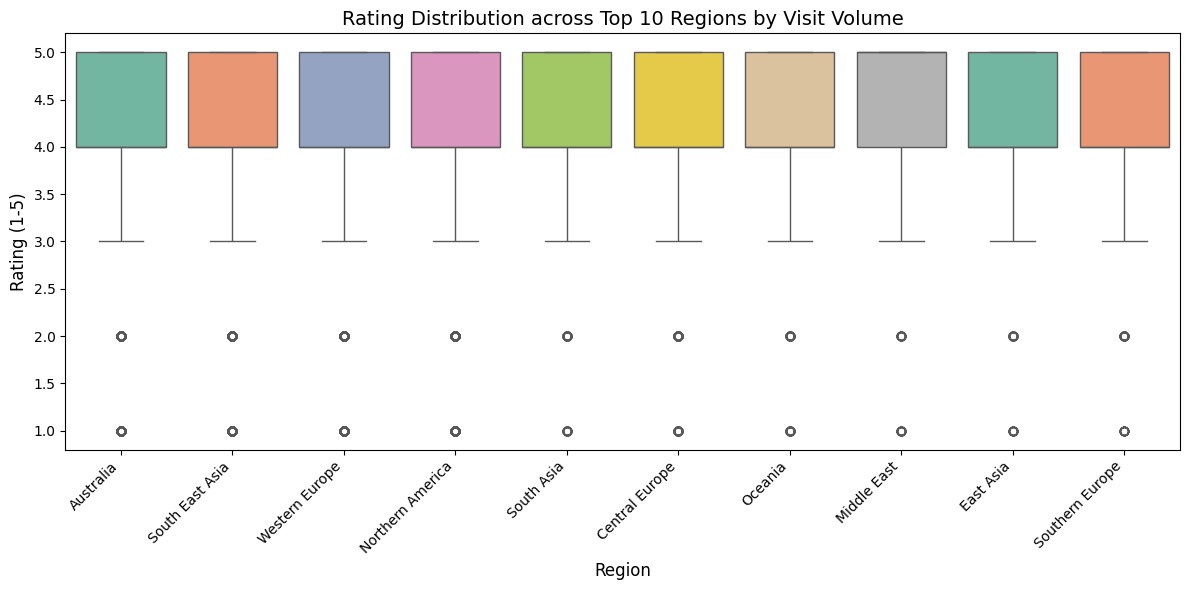

In [66]:
# Analyze distribution of ratings across different attractions and regions.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns


# ---------------------------------------------------------
# 1. Distribution Analysis across Regions
# ---------------------------------------------------------
def analyze_ratings_by_region(df, top_n=10):
    """Computes summary statistics and generates comparative boxplots for top regions."""
    # Group statistics by Region
    region_stats = (
        df.groupby("Region")
        .agg(
            total_ratings=("Rating", "count"),
            mean_rating=("Rating", "mean"),
            std_rating=("Rating", "std"),
            median_rating=("Rating", "median"),
            iqr_rating=(
                "Rating",
                lambda x: x.quantile(0.75) - x.quantile(0.25),
            ),
        )
        .sort_values(by="total_ratings", ascending=False)
        .reset_index()
    )

    # Static Boxplot (Seaborn)
    top_regions = region_stats.head(top_n)["Region"].tolist()
    df_top_regions = df[df["Region"].isin(top_regions)]

    plt.figure(figsize=(12, 6))
    sns.boxplot(
        data=df_top_regions,
        x="Region",
        y="Rating",
        order=top_regions,
        palette="Set2",
    )
    plt.xticks(rotation=45, ha="right")
    plt.title(
        f"Rating Distribution across Top {top_n} Regions by Visit Volume",
        fontsize=14,
    )
    plt.xlabel("Region", fontsize=12)
    plt.ylabel("Rating (1-5)", fontsize=12)
    plt.tight_layout()
    plt.show()

    return region_stats


# ---------------------------------------------------------
# 2. Distribution Analysis across Attractions
# ---------------------------------------------------------
def analyze_ratings_by_attraction(df, min_reviews=5, top_n=15):
    """Analyzes top and bottom rated attractions with a minimum review threshold."""
    attraction_col = (
        "Attraction" if "Attraction" in df.columns else "AttractionId"
    )

    attraction_stats = (
        df.groupby(attraction_col)
        .agg(
            total_reviews=("Rating", "count"),
            avg_rating=("Rating", "mean"),
            std_rating=("Rating", "std"),
        )
        .reset_index()
    )

    # Filter out attractions with very low review counts to avoid skewed averages
    attraction_filtered = attraction_stats[
        attraction_stats["total_reviews"] >= min_reviews
    ].copy()
    attraction_filtered = attraction_filtered.sort_values(
        by="avg_rating", ascending=False
    )

    # Interactive Bar Chart for Top & Bottom Rated Attractions (Plotly)
    top_attractions = attraction_filtered.head(top_n)
    bottom_attractions = attraction_filtered.tail(top_n)
    combined = pd.concat([top_attractions, bottom_attractions])

    fig = px.bar(
        combined,
        x="avg_rating",
        y=attraction_col,
        color="total_reviews",
        orientation="h",
        title=f"Top and Bottom {top_n} Attractions by Average Rating (Min {min_reviews} Reviews)",
        labels={
            "avg_rating": "Average Rating",
            attraction_col: "Attraction",
            "total_reviews": "Total Reviews",
        },
        color_continuous_scale="Viridis",
    )
    fig.update_layout(height=600, yaxis={"categoryorder": "total ascending"})

    return attraction_filtered, fig


# Example Execution:
region_summary = analyze_ratings_by_region(consolidated_df, top_n=10)
attraction_summary, fig_attractions = analyze_ratings_by_attraction(consolidated_df, min_reviews=10)
fig_attractions.show()

# **4. Model Training**

### **Regression Task**

In [67]:
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor


def prepare_regression_features(df):
    """Selects and encodes input features for rating prediction."""
    # 1. Feature Selection as specified in project requirements
    feature_cols = [
        "ContinentId",
        "RegionId",
        "CountryId",
        "CityId",  # User Demographics
        "VisitYear",
        "VisitMonth",
        "VisitModeId",  # Visit Details[cite: 2]
        "AttractionTypeId",
        "AttractionCityId",  # Attraction Attributes[cite: 2]
    ]

    target_col = "Rating"  # Continuous Target Variable (1-5 scale)[cite: 2]

    # Handle optional engineered features if available[cite: 2]
    optional_cols = ["avg_rating_user", "avg_rating_attraction"]
    for col in optional_cols:
        if col in df.columns:
            feature_cols.append(col)

    # 2. Filter available columns and drop NaNs
    valid_cols = [c for c in feature_cols if c in df.columns]
    data = df[valid_cols + [target_col]].dropna()

    X = data[valid_cols]
    y = data[target_col]

    return X, y


def train_and_evaluate_rating_regressors(X, y):
    """Trains multiple regression models and evaluates performance using R2, MSE, and RMSE[cite: 2]."""

    # Split dataset (80% Train, 20% Test)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Define Regression Models
    models = {
        "Random Forest Regressor": RandomForestRegressor(
            n_estimators=100, random_state=42
        ),
        "LightGBM Regressor": LGBMRegressor(
            n_estimators=100, learning_rate=0.05, random_state=42
        ),
        "XGBoost Regressor": XGBRegressor(
            n_estimators=100, learning_rate=0.05, random_state=42
        ),
    }

    results = []

    # Train and evaluate each model
    for name, model in models.items():
        # Train
        model.fit(X_train, y_train)

        # Predict
        y_pred = model.predict(X_test)

        # Clip predictions to logical rating boundary [1.0, 5.0][cite: 2]
        y_pred = np.clip(y_pred, 1.0, 5.0)

        # Calculate Evaluation Metrics[cite: 2]
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        results.append(
            {
                "Model": name,
                "MSE": round(mse, 4),
                "RMSE": round(rmse, 4),
                "MAE": round(mae, 4),
                "R2 Score": round(r2, 4),
            }
        )

    results_df = pd.DataFrame(results).sort_values(
        by="R2 Score", ascending=False
    )
    return results_df, models


# Example Execution:
X, y = prepare_regression_features(consolidated_df)
evaluation_metrics, trained_models = train_and_evaluate_rating_regressors(X, y)
print(evaluation_metrics)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000665 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 450
[LightGBM] [Info] Number of data points in the train set: 42312, number of used features: 7
[LightGBM] [Info] Start training from score 4.156929
                     Model     MSE    RMSE     MAE  R2 Score
2        XGBoost Regressor  0.8310  0.9116  0.7148    0.1049
1       LightGBM Regressor  0.8319  0.9121  0.7153    0.1039
0  Random Forest Regressor  0.9693  0.9845  0.7551   -0.0440


### **Classification Task**

In [68]:
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

def prepare_classification_features(df):
    """
    Prepares features and label-encoded target variable for VisitMode classification.
    """
    # 1. Feature Selection (Demographics, Transaction, Attraction details)
    feature_cols = [
        'ContinentId', 'RegionId', 'CountryId', 'CityId',   # User Demographics[cite: 2]
        'VisitYear', 'VisitMonth',                          # Historical Visit Details[cite: 2]
        'AttractionTypeId', 'AttractionCityId'              # Attraction Attributes[cite: 2]
    ]
    
    # Include rating if available in transaction data[cite: 2]
    if 'Rating' in df.columns:
        feature_cols.append('Rating')
        
    target_col = 'VisitMode'  # Target Category (Business, Family, Couples, Friends, etc.)[cite: 2]
    
    # Filter available columns and drop NaNs
    valid_cols = [c for c in feature_cols if c in df.columns]
    data = df[valid_cols + [target_col]].dropna()
    
    X = data[valid_cols]
    
    # Encode categorical target variable (VisitMode) into numeric IDs
    le_target = LabelEncoder()
    y = le_target.fit_transform(data[target_col].astype(str))
    
    return X, y, le_target

def train_and_evaluate_visitmode_classifiers(X, y, target_encoder):
    """
    Trains Random Forest, LightGBM, and XGBoost classifiers and evaluates using Accuracy, Precision, Recall, and F1-score[cite: 2].
    """
    # Stratified Train-Test Split (80% Train, 20% Test) to preserve class balance
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Define Classification Models[cite: 2]
    models = {
        'Random Forest Classifier': RandomForestClassifier(n_estimators=100, random_state=42),
        'LightGBM Classifier': LGBMClassifier(n_estimators=100, learning_rate=0.05, random_state=42),
        'XGBoost Classifier': XGBClassifier(n_estimators=100, learning_rate=0.05, random_state=42, eval_metric='mlogloss')
    }
    
    results = []
    
    for name, model in models.items():
        # Train
        model.fit(X_train, y_train)
        
        # Predict
        y_pred = model.predict(X_test)
        
        # Calculate Weighted Classification Metrics[cite: 2]
        acc = accuracy_score(y_test, y_pred)
        precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
        
        results.append({
            'Model': name,
            'Accuracy': round(acc, 4),
            'Precision': round(precision, 4),
            'Recall': round(recall, 4),
            'F1-Score': round(f1, 4)
        })
        
        print(f"\n--- Detailed Classification Report: {name} ---")
        print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))
        
    results_df = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False)
    return results_df, models

# Example Execution:
X_cls, y_cls, target_le = prepare_classification_features(consolidated_df)
classification_metrics, trained_classifiers = train_and_evaluate_visitmode_classifiers(X_cls, y_cls, target_le)
print(classification_metrics)


--- Detailed Classification Report: Random Forest Classifier ---
              precision    recall  f1-score   support

           1       0.30      0.17      0.22       125
           2       0.53      0.65      0.58      4320
           3       0.49      0.46      0.47      3042
           4       0.39      0.31      0.34      2188
           5       0.33      0.21      0.26       903

    accuracy                           0.48     10578
   macro avg       0.41      0.36      0.37     10578
weighted avg       0.47      0.48      0.47     10578

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003339 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 454
[LightGBM] [Info] Number of data points in the train set: 42312, number of used features: 8
[LightGBM] [Info] Start training from score -4.442226
[LightGBM] [Info] Start training from score -0.895347
[LightGBM] [Info] Start training from score -1.246

### **Recommendation Task**

In [69]:
# Implement collaborative filtering (using user-item matrix) to recommend attractions based on user ratings and preferences.

import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity


class UserCollaborativeRecommender:

    def __init__(self, top_k_neighbors=5):
        """User-Based Collaborative Filtering System using Cosine Similarity."""
        self.top_k_neighbors = top_k_neighbors
        self.user_item_matrix = None
        self.user_sim_df = None

    def fit(self, df):
        """Builds user-item interaction matrix and user similarity matrix."""
        # Create User-Item Matrix (Rows: UserId, Columns: AttractionId, Values: Rating)
        self.user_item_matrix = df.pivot_table(
            index="UserId", columns="AttractionId", values="Rating"
        )

        # Fill NaNs with 0 for vector similarity calculations
        matrix_filled = self.user_item_matrix.fillna(0)

        # Compute Cosine Similarity between all users
        user_sim_matrix = cosine_similarity(matrix_filled)

        self.user_sim_df = pd.DataFrame(
            user_sim_matrix,
            index=self.user_item_matrix.index,
            columns=self.user_item_matrix.index,
        )
        print(
            f"User-Item Matrix built with shape: {self.user_item_matrix.shape}"
        )

    def recommend(self, user_id, top_n=5, item_metadata_df=None):
        if user_id not in self.user_item_matrix.index:
            raise ValueError(f"UserId '{user_id}' not found in user-item matrix.")
    
        # 1. Get similar users
        similar_users = self.user_sim_df[user_id].drop(user_id)
    
        # Filter out users with 0 or negative similarity
        positive_similar_users = similar_users[similar_users > 0]
    
        if len(positive_similar_users) == 0:
            # Fallback A: If no similar users exist, return global top-rated attractions
            global_means = self.user_item_matrix.mean(axis=0)
            user_ratings = self.user_item_matrix.loc[user_id]
            unvisited = global_means.drop(
                index=user_ratings[user_ratings.notna()].index, errors="ignore"
            )
            top_recommendations = (
                unvisited.sort_values(ascending=False).head(top_n).reset_index()
            )
            top_recommendations.columns = ["AttractionId", "PredictedScore"]
        else:
            top_similar_users = positive_similar_users.nlargest(
                self.top_k_neighbors
            ).index
    
            # 2. Get unvisited attractions
            user_ratings = self.user_item_matrix.loc[user_id]
            visited_attractions = user_ratings[user_ratings.notna()].index
    
            # 3. Calculate weighted average ratings
            similar_users_matrix = self.user_item_matrix.loc[top_similar_users]
            weights = self.user_sim_df.loc[user_id, top_similar_users].values
    
            # Compute dot product
            weighted_sum = similar_users_matrix.T.dot(weights)
    
            # Compute sum of weights for items that were actually rated by similar users
            sum_of_weights = np.dot((~similar_users_matrix.isna()).T, weights)
    
            # Avoid division by zero
            with np.errstate(divide="ignore", invalid="ignore"):
                predicted_scores = weighted_sum / sum_of_weights
    
            # Drop already visited attractions
            recommendations = predicted_scores.drop(
                index=visited_attractions, errors="ignore"
            )
    
            # Fallback B: Fill remaining NaNs with overall average attraction ratings
            attraction_means = self.user_item_matrix.mean(axis=0)
            recommendations = recommendations.fillna(attraction_means)
    
            top_recommendations = (
                recommendations.sort_values(ascending=False)
                .head(top_n)
                .reset_index()
            )
            top_recommendations.columns = ["AttractionId", "PredictedScore"]
    
        # Merge metadata if available
        if item_metadata_df is not None:
            attr_cols = [
                c
                for c in [
                    "AttractionId",
                    "Attraction",
                    "AttractionType",
                    "CityName",
                ]
                if c in item_metadata_df.columns
            ]
            meta = item_metadata_df[attr_cols].drop_duplicates(
                subset=["AttractionId"]
            )
            top_recommendations = top_recommendations.merge(
                meta, on="AttractionId", how="left"
            )

        return top_recommendations


# Example Execution:
recommender = UserCollaborativeRecommender(top_k_neighbors=10)
recommender.fit(consolidated_df)
top_5_recommendations = recommender.recommend(user_id=476, top_n=5, item_metadata_df=item)
print(top_5_recommendations)

User-Item Matrix built with shape: (33530, 30)
   AttractionId  PredictedScore                          Attraction
0           947        4.698795                Mount Semeru Volcano
1           841        4.647235                       Waterbom Bali
2           888        4.611549  Bromo Tengger Semeru National Park
3           928        4.571429     Khayangan Reflexology & Massage
4          1133        4.512605                       Jomblang Cave


In [70]:
# Alternatively, use content-based filtering based on attractions' attributes (e.g., location, type).

import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity


class ContentBasedRecommender:

    def __init__(self):
        """Content-Based Filtering System using attraction metadata features (type, location, etc.)."""
        self.item_features_df = None
        self.similarity_matrix = None
        self.item_ids = []

    def fit(self, df_items):
        """Builds attraction feature matrix using one-hot encoded metadata and computes similarity matrix."""
        # Select relevant attribute columns
        feature_cols = [
            col
            for col in [
                "AttractionTypeId",
                "AttractionCityId",
                "CountryId",
                "RegionId",
            ]
            if col in df_items.columns
        ]

        # Deduplicate items by AttractionId
        items_clean = df_items[
            ["AttractionId"] + feature_cols
        ].drop_duplicates(subset=["AttractionId"])
        self.item_ids = items_clean["AttractionId"].values

        # One-hot encode categorical features (Type, Location, Country)
        encoded_features = pd.get_dummies(
            items_clean[feature_cols].astype(str), drop_first=False
        )
        self.item_features_df = pd.DataFrame(
            encoded_features.values, index=items_clean["AttractionId"]
        )

        # Compute Cosine Similarity between attraction feature vectors
        self.similarity_matrix = pd.DataFrame(
            cosine_similarity(self.item_features_df),
            index=self.item_ids,
            columns=self.item_ids,
        )
        print(
            f"Content-Based Similarity Matrix created for {len(self.item_ids)} attractions."
        )

    def recommend_for_user(
        self, user_id, df_transactions, top_n=5, item_metadata_df=None
    ):
        """Generates recommendations by creating a weighted user profile from high-rated past visits."""
        # Get user's transaction history
        user_history = df_transactions[df_transactions["UserId"] == user_id]

        if user_history.empty:
            # Fallback for cold-start user: return globally popular attractions
            top_popular = (
                df_transactions.groupby("AttractionId")["Rating"]
                .agg(["count", "mean"])
                .sort_values(by=["count", "mean"], ascending=False)
                .head(top_n)
                .reset_index()
            )
            top_popular.columns = ["AttractionId", "VisitCount", "AvgRating"]
            if item_metadata_df is not None:
                top_popular = top_popular.merge(
                    item_metadata_df.drop_duplicates("AttractionId"),
                    on="AttractionId",
                    how="left",
                )
            return top_popular

        # Filter positive preferences (e.g., attractions rated >= 3.0)
        liked_history = user_history[user_history["Rating"] >= 3.0]
        if liked_history.empty:
            liked_history = user_history  # Use all visited if none rated high

        visited_ids = user_history["AttractionId"].unique()

        # Compute User Preference Profile Vector (weighted sum of liked attraction vectors)
        user_profile = np.zeros(self.item_features_df.shape[1])
        total_weight = 0

        for _, row in liked_history.iterrows():
            attr_id = row["AttractionId"]
            rating = row["Rating"]
            if attr_id in self.item_features_df.index:
                user_profile += (
                    self.item_features_df.loc[attr_id].values * rating
                )
                total_weight += rating

        if total_weight > 0:
            user_profile /= total_weight

        # Calculate similarity score between User Profile and all attractions
        scores = cosine_similarity(
            user_profile.reshape(1, -1), self.item_features_df.values
        ).flatten()
        similarity_series = pd.Series(scores, index=self.item_features_df.index)

        # Exclude already visited attractions
        unvisited_recommendations = similarity_series.drop(
            index=visited_ids, errors="ignore"
        )

        top_recommendations = (
            unvisited_recommendations.sort_values(ascending=False)
            .head(top_n)
            .reset_index()
        )
        top_recommendations.columns = ["AttractionId", "SimilarityScore"]

        # Merge metadata for display (Name, Type, City)
        if item_metadata_df is not None:
            attr_cols = [
                c
                for c in [
                    "AttractionId",
                    "Attraction",
                    "AttractionType",
                    "CityName",
                ]
                if c in item_metadata_df.columns
            ]
            meta = item_metadata_df[attr_cols].drop_duplicates(
                subset=["AttractionId"]
            )
            top_recommendations = top_recommendations.merge(
                meta, on="AttractionId", how="left"
            )

        return top_recommendations


# Example Execution:
cb_recommender = ContentBasedRecommender()
cb_recommender.fit(item)  # Item DataFrame containing metadata attributes
top_5_cb = cb_recommender.recommend_for_user(user_id=480, df_transactions=consolidated_df, top_n=5, item_metadata_df=item)
print(top_5_cb)

Content-Based Similarity Matrix created for 30 attractions.
   AttractionId  SimilarityScore            Attraction
0           369         0.593732     Kuta Beach - Bali
1           481         0.593732        Nusa Dua Beach
2           650         0.593732           Sanur Beach
3           673         0.593732        Seminyak Beach
4           749         0.593732  Tegenungan Waterfall


# **5. Model Performance**

In [71]:
# Classification model Performance Covered

# Regression model Performance Covered

In [72]:
from sklearn.model_selection import train_test_split

# 1. Split consolidated dataset into train_df (80%) and test_df (20%)
train_df, test_df = train_test_split(
    consolidated_df, test_size=0.2, random_state=42
)

# 2. Fit the Collaborative Recommender on the training set only
recommender = UserCollaborativeRecommender(top_k_neighbors=10)
recommender.fit(train_df)

User-Item Matrix built with shape: (28700, 30)


In [73]:
# Assess recommendation system accuracy

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error


def evaluate_recommendation_system(
    test_df, recommender, k_values=[5, 10], fallback_score=3.0
):
    """Evaluates recommendation system using RMSE (Rating Prediction) and MAP@K (Ranking Quality)[cite: 1, 2]."""
    actual_ratings = []
    predicted_ratings = []
    apk_list = {k: [] for k in k_values}

    # Group test dataset by user
    user_test_groups = test_df.groupby("UserId")

    for user_id, group in user_test_groups:
        if user_id not in recommender.user_item_matrix.index:
            continue  # Skip unindexed cold users

        # 1. Compute RMSE for actual vs predicted ratings[cite: 1, 2]
        actual_visited = group["AttractionId"].values
        actual_scores = group["Rating"].values

        for attr_id, act_rating in zip(actual_visited, actual_scores):
            # Fetch predicted score from recommender interaction matrix
            try:
                pred_rating = recommender.user_item_matrix.loc[
                    user_id, attr_id
                ]
                if np.isnan(pred_rating) or pred_rating == 0:
                    pred_rating = fallback_score
            except KeyError:
                pred_rating = fallback_score

            actual_ratings.append(act_rating)
            predicted_ratings.append(pred_rating)

        # 2. Compute MAP@K (Mean Average Precision)[cite: 1, 2]
        # Relevant items = items rated >= 4.0 by user in test set
        relevant_items = group[group["Rating"] >= 4.0]["AttractionId"].tolist()

        if relevant_items:
            # Generate top-N recommendations for user
            try:
                recs_df = recommender.recommend(
                    user_id=user_id, top_n=max(k_values)
                )
                recommended_items = recs_df["AttractionId"].tolist()

                for k in k_values:
                    # Compute Average Precision at K (AP@K)
                    recs_at_k = recommended_items[:k]
                    hits = 0
                    sum_precisions = 0.0

                    for i, item in enumerate(recs_at_k):
                        if item in relevant_items:
                            hits += 1
                            sum_precisions += hits / (i + 1.0)

                    ap_k = sum_precisions / min(len(relevant_items), k)
                    apk_list[k].append(ap_k)
            except Exception:
                continue

    # Summary Metrics Calculation
    rec_rmse = np.sqrt(mean_squared_error(actual_ratings, predicted_ratings))

    results = {"Recommendation Metric": ["RMSE"], "Value": [round(rec_rmse, 4)]}

    for k in k_values:
        map_k = np.mean(apk_list[k]) if apk_list[k] else 0.0
        results["Recommendation Metric"].append(f"MAP@{k}")
        results["Value"].append(round(map_k, 4))

    return pd.DataFrame(results)


# Example Execution:
rec_eval_df = evaluate_recommendation_system(test_df, recommender, k_values=[5, 10])
print(rec_eval_df)

  Recommendation Metric   Value
0                  RMSE  1.2631
1                 MAP@5  0.0361
2                MAP@10  0.0555


# **6. Deployment**

In [74]:
import joblib

# Save pre-trained models & metadata mappings
joblib.dump(trained_classifiers["LightGBM Classifier"], "classifier_model.pkl")
joblib.dump(target_le, "visit_mode_encoder.pkl")
joblib.dump(recommender, "collaborative_recommender.pkl")

# Save cleaned datasets for app usage
consolidated_df.to_pickle("consolidated_df.pkl")
item.to_pickle("item.pkl")
city.to_pickle("city.pkl")